# Plasticity probe via Hessian eigenvalue density before and after MNIST training

This notebook tests whether an MLP's local ability to change its predictions changes after training.

Core idea:

1. Initialize an MLP.
2. Freeze the current predictions with `detach()`.
3. Draw random perturbations `epsilon ~ N(0, 1)`.
4. Define a probe loss

\[
\ell(\theta) = \frac{1}{B}\sum_i \|f_\theta(x_i) - \operatorname{stopgrad}(f_\theta(x_i)) + \epsilon_i\|^2
\]

5. Compute the exact Hessian of this probe loss with respect to all parameters.
6. Plot the Hessian eigenvalue density.
7. Train the same network on MNIST classification.
8. Repeat the probe and compare the before/after spectra.

Notes:

- Exact Hessians scale as `num_parameters ** 2`, so the default model is intentionally small.
- Increase `hidden_width` only after checking memory.
- The probe loss follows the same spirit as the plasticity/loss-landscape experiment in Lyle et al. (2023), but here it is adapted to a simple supervised MNIST MLP.


In [1]:
# If needed, uncomment these in a fresh environment.
# !pip install torch torchvision matplotlib numpy tqdm

import copy
import math
import random
from collections import OrderedDict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.func import functional_call
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


/Users/mahdigheidi/Documents/Univ/Masters-Study-Project/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Reproducibility and device
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Exact Hessian is most practical on CPU for small models.
# Training can use CUDA/MPS if available, then we copy back to CPU for Hessian.
if torch.cuda.is_available():
    train_device = torch.device('cuda')
elif torch.backends.mps.is_available():
    train_device = torch.device('mps')
else:
    train_device = torch.device('cpu')

hessian_device = torch.device('cpu')
print('Training device:', train_device)
print('Hessian device:', hessian_device)


Training device: mps
Hessian device: cpu


In [3]:
# Hyperparameters
hidden_width = 8          # Keep small for exact Hessian. Try 16 only if you have enough RAM/time.
train_epochs = 10
batch_size = 128
learning_rate = 1e-3

# Probe settings
probe_batch_size = 32     # Batch used for Hessian probe loss
num_density_points = 600
kde_bandwidth = None      # None = automatic Silverman-like bandwidth

# Optional: use a smaller MNIST subset for faster experimentation.
use_train_subset = True
train_subset_size = 10_000


In [4]:
# MNIST data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset_full = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

if use_train_subset:
    indices = torch.randperm(len(train_dataset_full))[:train_subset_size].tolist()
    train_dataset = Subset(train_dataset_full, indices)
else:
    train_dataset = train_dataset_full

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

# Fixed probe batch. Keep this fixed before/after training for a fair comparison.
probe_loader = DataLoader(train_dataset_full, batch_size=probe_batch_size, shuffle=True)
probe_x, probe_y = next(iter(probe_loader))
probe_x = probe_x.to(hessian_device)
print('Probe batch:', probe_x.shape)


Probe batch: torch.Size([32, 1, 28, 28])


In [5]:
class SmallMLP(nn.Module):
    def __init__(self, hidden_width=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden_width),
            nn.ReLU(),
            nn.Linear(hidden_width, 10),
        )

    def forward(self, x):
        return self.net(x)

model = SmallMLP(hidden_width=hidden_width).to(train_device)
num_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'Number of parameters: {num_params:,}')
print(f'Exact Hessian elements: {num_params**2:,} (~{num_params**2 * 4 / 1e9:.2f} GB in float32)')


SmallMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=8, bias=True)
    (2): ReLU()
    (3): Linear(in_features=8, out_features=10, bias=True)
  )
)
Number of parameters: 6,370
Exact Hessian elements: 40,576,900 (~0.16 GB in float32)


In [6]:
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            total_loss += loss.item() * x.size(0)
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total += x.size(0)
    return total_loss / total, total_correct / total


def train_mnist(model, train_loader, test_loader, device, epochs=3, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'epoch': [], 'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        total = 0

        pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}', leave=False)
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            running_correct += (logits.argmax(dim=1) == y).sum().item()
            total += x.size(0)
            pbar.set_postfix(loss=running_loss / total, acc=running_correct / total)

        train_loss = running_loss / total
        train_acc = running_correct / total
        test_loss, test_acc = evaluate(model, test_loader, device)

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f'Epoch {epoch:02d} | train loss {train_loss:.4f} | train acc {train_acc:.3f} | test acc {test_acc:.3f}')

    return history


In [7]:
def flatten_params(named_params):
    flat_parts = []
    shapes = OrderedDict()
    sizes = OrderedDict()
    for name, p in named_params:
        shapes[name] = p.shape
        sizes[name] = p.numel()
        flat_parts.append(p.detach().reshape(-1).to(torch.float32))
    return torch.cat(flat_parts), shapes, sizes


def unflatten_params(theta_flat, shapes, sizes):
    params = OrderedDict()
    idx = 0
    for name in shapes:
        n = sizes[name]
        params[name] = theta_flat[idx:idx+n].reshape(shapes[name])
        idx += n
    return params


def make_probe_target(model_cpu, x_probe):
    '''stopgrad(f_theta(X)) - epsilon, so loss is ||f_theta(X) - target||^2.'''
    model_cpu.eval()
    with torch.no_grad():
        y_stop = model_cpu(x_probe).detach()
        epsilon = torch.randn_like(y_stop)
        target = y_stop - epsilon
    return target, epsilon


def exact_probe_hessian_and_eigs(model, x_probe):
    '''Compute exact Hessian of MSE(f_theta(x), stopgrad(f_theta(x)) - epsilon).'''
    model_cpu = copy.deepcopy(model).to(hessian_device).eval()
    model_cpu = model_cpu.float()
    x_probe = x_probe.to(hessian_device).float()

    theta0, shapes, sizes = flatten_params(model_cpu.named_parameters())
    theta0 = theta0.detach().clone().requires_grad_(True)
    buffers = OrderedDict((name, b.detach()) for name, b in model_cpu.named_buffers())

    target, epsilon = make_probe_target(model_cpu, x_probe)

    def loss_from_flat(theta_flat):
        params = unflatten_params(theta_flat, shapes, sizes)
        logits = functional_call(model_cpu, (params, buffers), (x_probe,))
        return F.mse_loss(logits, target, reduction='mean')

    print('Computing exact Hessian. This can take time for larger hidden_width values.')
    H = torch.autograd.functional.hessian(loss_from_flat, theta0, vectorize=True)
    H = H.detach().cpu()
    H = 0.5 * (H + H.T)  # numerical symmetrization

    eigvals = torch.linalg.eigvalsh(H).numpy()
    probe_loss = loss_from_flat(theta0).detach().item()

    return H.numpy(), eigvals, probe_loss, epsilon.detach().cpu().numpy()


def kde_density(eigvals, num_points=600, bandwidth=None):
    eigvals = np.asarray(eigvals, dtype=np.float64)
    lo, hi = eigvals.min(), eigvals.max()
    pad = 0.05 * max(hi - lo, 1e-8)
    grid = np.linspace(lo - pad, hi + pad, num_points)
    n = len(eigvals)

    if bandwidth is None:
        std = np.std(eigvals)
        iqr = np.subtract(*np.percentile(eigvals, [75, 25]))
        sigma = min(std, iqr / 1.34) if iqr > 0 else std
        bandwidth = 0.9 * sigma * n ** (-1/5) if sigma > 0 else 1e-3
        bandwidth = max(bandwidth, 1e-6)

    z = (grid[:, None] - eigvals[None, :]) / bandwidth
    density = np.exp(-0.5 * z**2).mean(axis=1) / (bandwidth * np.sqrt(2 * np.pi))
    return grid, density, bandwidth


def summarize_spectrum(eigvals, name):
    eigvals = np.asarray(eigvals)
    print(f'--- {name} spectrum summary ---')
    print(f'count:       {len(eigvals):,}')
    print(f'min:         {eigvals.min(): .6e}')
    print(f'max:         {eigvals.max(): .6e}')
    print(f'mean:        {eigvals.mean(): .6e}')
    print(f'median:      {np.median(eigvals): .6e}')
    print(f'negatives:   {(eigvals < -1e-7).sum():,}')
    print(f'near zero:   {(np.abs(eigvals) <= 1e-7).sum():,}')
    print(f'positives:   {(eigvals > 1e-7).sum():,}')


## 1. Hessian spectrum at initialization

In [8]:
initial_state = copy.deepcopy(model.state_dict())

H_init, eig_init, probe_loss_init, eps_init = exact_probe_hessian_and_eigs(model, probe_x)
summarize_spectrum(eig_init, 'initialization')
print('Probe loss at initialization:', probe_loss_init)


Computing exact Hessian. This can take time for larger hidden_width values.
--- initialization spectrum summary ---
count:       6,370
min:         -6.825470e-01
max:          2.436372e+01
mean:         3.370859e-02
median:       1.489619e-11
negatives:   461
near zero:   5,404
positives:   505
Probe loss at initialization: 0.9815214276313782


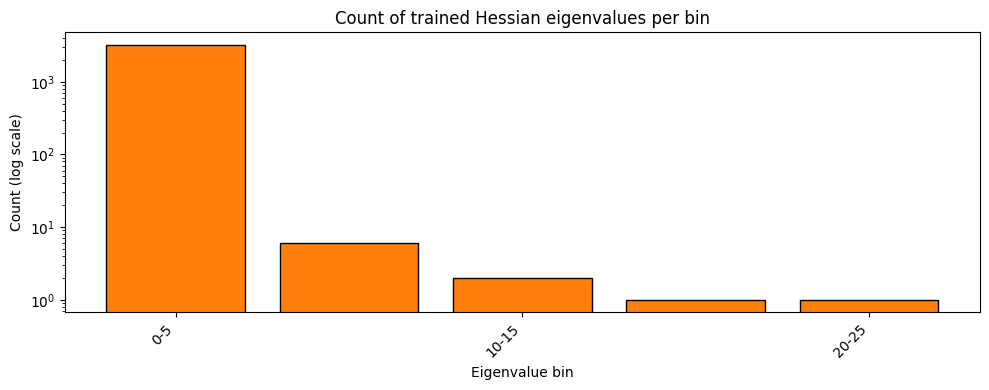

Negative eigenvalues: 0


In [28]:
eig_init_pos = eig_init[eig_init >= 0]
bin_width = 5
max_edge = np.ceil(eig_init_pos.max() / bin_width) * bin_width
bins = np.arange(0, max_edge + bin_width, bin_width)

counts, edges = np.histogram(eig_init_pos, bins=bins)
bin_labels = [f'{int(edges[i])}-{int(edges[i+1])}' for i in range(len(edges) - 1)]

plt.figure(figsize=(10, 4))
plt.bar(range(len(counts)), counts, width=0.8, color='C1', edgecolor='k')
plt.yscale('log')
plt.xticks(
    np.arange(0, len(bin_labels), 2),
    [bin_labels[i] for i in range(0, len(bin_labels), 2)],
    rotation=45,
    ha='right',
)
plt.xlabel('Eigenvalue bin')
plt.ylabel('Count (log scale)')
plt.title('Count of trained Hessian eigenvalues per bin')
plt.tight_layout()
plt.show()

print('Negative eigenvalues:', int((eig_init_pos < 0).sum()))

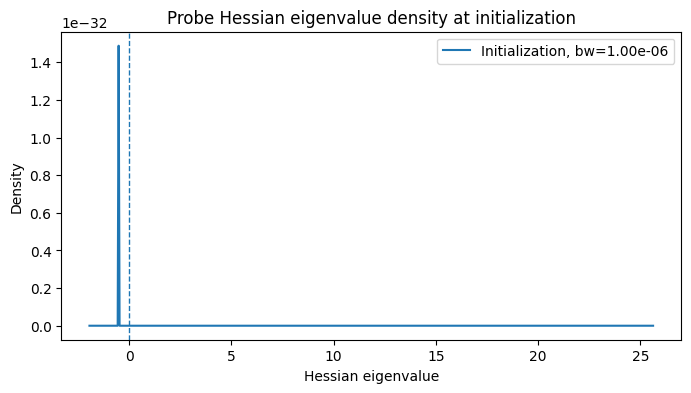

In [9]:
grid_init, dens_init, bw_init = kde_density(eig_init, num_points=num_density_points, bandwidth=kde_bandwidth)

plt.figure(figsize=(8, 4))
plt.plot(grid_init, dens_init, label=f'Initialization, bw={bw_init:.2e}')
plt.axvline(0.0, linestyle='--', linewidth=1)
plt.xlabel('Hessian eigenvalue')
plt.ylabel('Density')
plt.title('Probe Hessian eigenvalue density at initialization')
plt.legend()
plt.show()


## 2. Train the MLP on MNIST

In [10]:
history = train_mnist(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    device=train_device,
    epochs=train_epochs,
    lr=learning_rate,
)


Epoch 01 | train loss 1.6735 | train acc 0.381 | test acc 0.601


Epoch 02 | train loss 0.9723 | train acc 0.701 | test acc 0.804


Epoch 03 | train loss 0.6135 | train acc 0.833 | test acc 0.860


Epoch 04 | train loss 0.4714 | train acc 0.866 | test acc 0.875


Epoch 05 | train loss 0.4099 | train acc 0.884 | test acc 0.888


Epoch 06 | train loss 0.3785 | train acc 0.892 | test acc 0.888


Epoch 07 | train loss 0.3580 | train acc 0.898 | test acc 0.894


Epoch 08 | train loss 0.3416 | train acc 0.901 | test acc 0.896


Epoch 09 | train loss 0.3312 | train acc 0.904 | test acc 0.898


Epoch 10 | train loss 0.3224 | train acc 0.907 | test acc 0.898


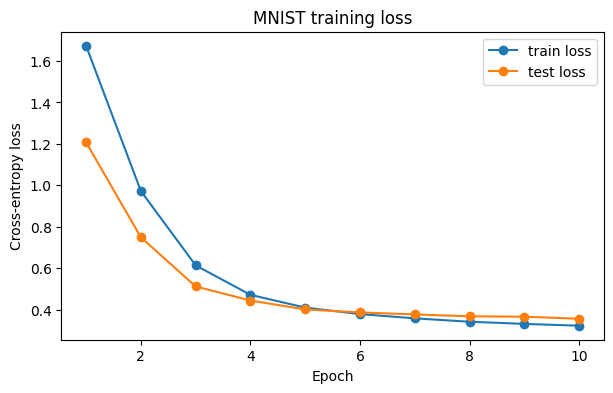

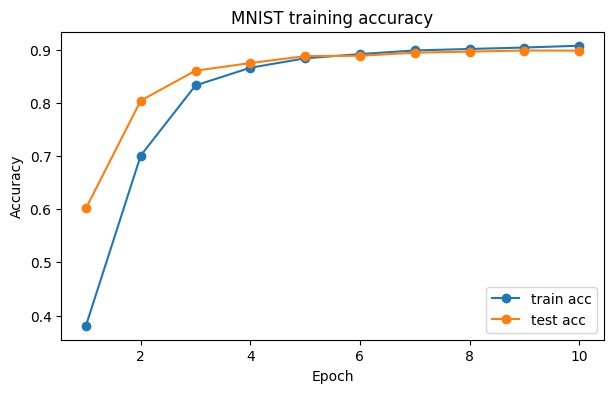

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(history['epoch'], history['train_loss'], marker='o', label='train loss')
plt.plot(history['epoch'], history['test_loss'], marker='o', label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('MNIST training loss')
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history['epoch'], history['train_acc'], marker='o', label='train acc')
plt.plot(history['epoch'], history['test_acc'], marker='o', label='test acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MNIST training accuracy')
plt.legend()
plt.show()


## 3. Hessian spectrum after MNIST training

In [12]:
H_trained, eig_trained, probe_loss_trained, eps_trained = exact_probe_hessian_and_eigs(model, probe_x)
summarize_spectrum(eig_trained, 'after MNIST training')

print('Probe loss after training:', probe_loss_trained)
print(eig_trained)


Computing exact Hessian. This can take time for larger hidden_width values.
--- after MNIST training spectrum summary ---
count:       6,370
min:         -1.059095e+00
max:          2.312808e+02
mean:         4.123598e-01
median:       0.000000e+00
negatives:   1,189
near zero:   3,768
positives:   1,413
Probe loss after training: 0.9320861101150513
[ -1.0590954  -0.9224762  -0.8495942 ... 190.43799   203.57318
 231.28079  ]


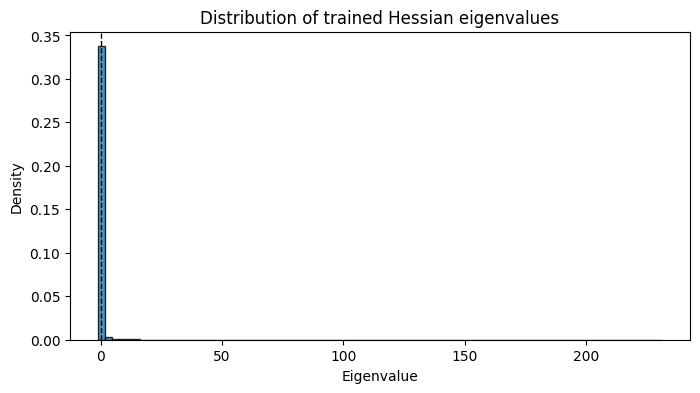

In [13]:
plt.figure(figsize=(8, 4))
plt.hist(eig_trained, bins=80, density=True, alpha=0.8, color='C0', edgecolor='black')
plt.axvline(0.0, color='k', linestyle='--', linewidth=1)
plt.xlabel('Eigenvalue')
plt.ylabel('Density')
plt.title('Distribution of trained Hessian eigenvalues')
plt.show()

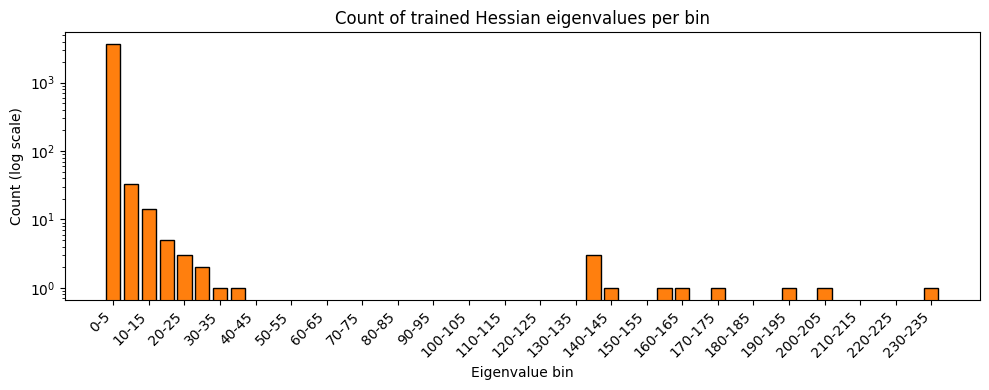

Negative eigenvalues: 2681


In [27]:
eig_trained_pos = eig_trained[eig_trained >= 0]
bin_width = 5
max_edge = np.ceil(eig_trained_pos.max() / bin_width) * bin_width
bins = np.arange(0, max_edge + bin_width, bin_width)

counts, edges = np.histogram(eig_trained_pos, bins=bins)
bin_labels = [f'{int(edges[i])}-{int(edges[i+1])}' for i in range(len(edges) - 1)]

plt.figure(figsize=(10, 4))
plt.bar(range(len(counts)), counts, width=0.8, color='C1', edgecolor='k')
plt.yscale('log')
plt.xticks(
    np.arange(0, len(bin_labels), 2),
    [bin_labels[i] for i in range(0, len(bin_labels), 2)],
    rotation=45,
    ha='right',
)
plt.xlabel('Eigenvalue bin')
plt.ylabel('Count (log scale)')
plt.title('Count of trained Hessian eigenvalues per bin')
plt.tight_layout()
plt.show()

print('Negative eigenvalues:', int((eig_trained < 0).sum()))

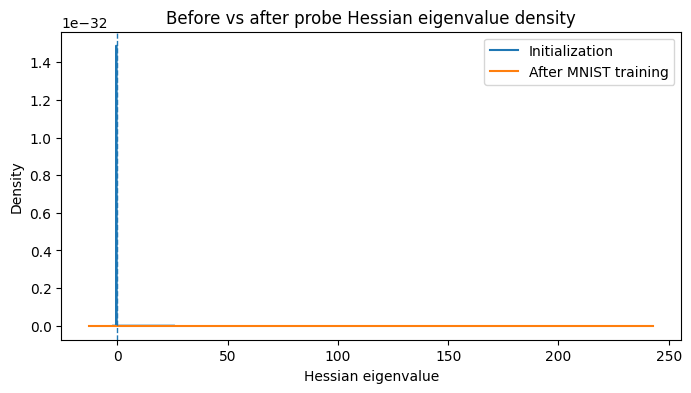

In [19]:
grid_trained, dens_trained, bw_trained = kde_density(eig_trained, num_points=num_density_points, bandwidth=kde_bandwidth)

plt.figure(figsize=(8, 4))
plt.plot(grid_init, dens_init, label='Initialization')
plt.plot(grid_trained, dens_trained, label='After MNIST training')
plt.axvline(0.0, linestyle='--', linewidth=1)
plt.xlabel('Hessian eigenvalue')
plt.ylabel('Density')
plt.title('Before vs after probe Hessian eigenvalue density')
plt.legend()
plt.show()


In [26]:
eig_trained[6250:]

array([  2.1937368,   2.2101476,   2.2801054,   2.3157954,   2.3597221,
         2.3851185,   2.3985066,   2.4815495,   2.494882 ,   2.5247698,
         2.5484076,   2.5526986,   2.6805153,   2.7063942,   2.718068 ,
         2.7869914,   2.8282886,   2.840521 ,   2.9351642,   2.9737248,
         2.992926 ,   3.0267887,   3.0464947,   3.1006274,   3.1692863,
         3.2434585,   3.2874112,   3.3581777,   3.3977556,   3.423842 ,
         3.4967892,   3.567866 ,   3.6350658,   3.6769018,   3.7157145,
         3.795578 ,   3.914478 ,   3.966896 ,   4.0528817,   4.1004043,
         4.16851  ,   4.2010818,   4.306179 ,   4.3870177,   4.447622 ,
         4.4558806,   4.5547047,   4.679714 ,   4.814455 ,   4.8997865,
         4.9791927,   5.1431675,   5.1992645,   5.3449216,   5.426494 ,
         5.4631467,   5.5519423,   5.633251 ,   5.7885947,   5.8902984,
         6.1594825,   6.2222123,   6.2725825,   6.4428654,   6.5587783,
         6.578158 ,   6.627015 ,   6.767666 ,   6.822186 ,   6.8

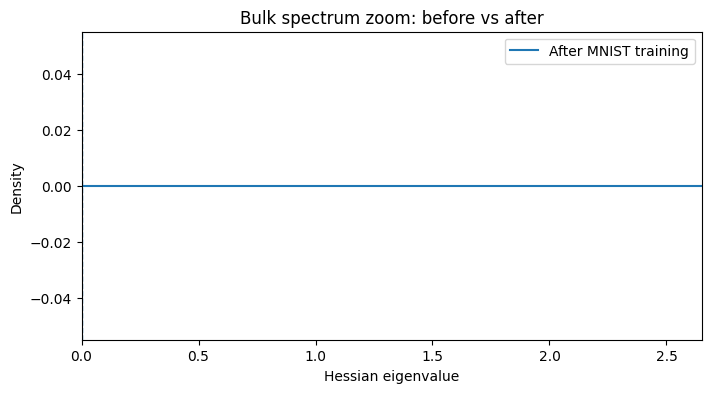

In [15]:
# Optional zoom around the bulk of the spectrum.
# This is useful when a few large outliers dominate the x-axis.
all_eigs = np.concatenate([eig_init, eig_trained])
lo, hi = np.percentile(all_eigs, [1, 99])

plt.figure(figsize=(8, 4))
# plt.plot(grid_init, dens_init, label='Initialization')
plt.plot(grid_trained, dens_trained, label='After MNIST training')
plt.axvline(0.0, linestyle='--', linewidth=1)
plt.xlim(lo, hi)
plt.xlabel('Hessian eigenvalue')
plt.ylabel('Density')
plt.title('Bulk spectrum zoom: before vs after')
plt.legend()
plt.show()


## 4. Direct numerical comparison

In [16]:
comparison = {
    'lambda_max_init': float(eig_init.max()),
    'lambda_max_trained': float(eig_trained.max()),
    'lambda_min_init': float(eig_init.min()),
    'lambda_min_trained': float(eig_trained.min()),
    'num_negative_init': int((eig_init < -1e-7).sum()),
    'num_negative_trained': int((eig_trained < -1e-7).sum()),
    'trace_init': float(eig_init.sum()),
    'trace_trained': float(eig_trained.sum()),
    'spectral_radius_init': float(np.max(np.abs(eig_init))),
    'spectral_radius_trained': float(np.max(np.abs(eig_trained))),
}
comparison


{'lambda_max_init': 24.363723754882812,
 'lambda_max_trained': 231.28079223632812,
 'lambda_min_init': -0.6825469732284546,
 'lambda_min_trained': -1.0590953826904297,
 'num_negative_init': 461,
 'num_negative_trained': 1189,
 'trace_init': 214.72372436523438,
 'trace_trained': 2626.731689453125,
 'spectral_radius_init': 24.363723754882812,
 'spectral_radius_trained': 231.28079223632812}

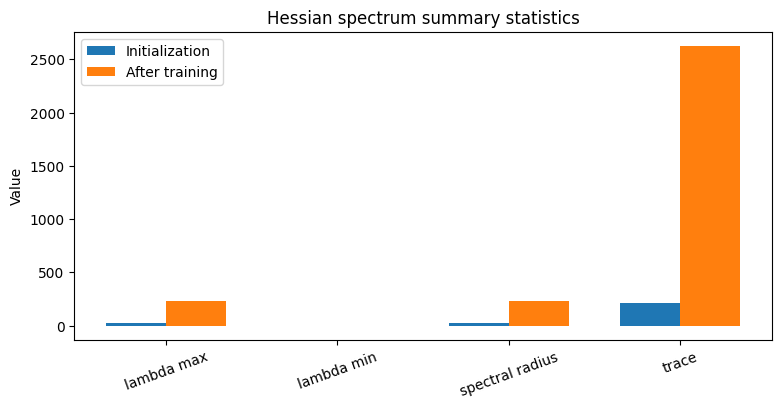

In [17]:
labels = ['lambda max', 'lambda min', 'spectral radius', 'trace']
init_vals = [comparison['lambda_max_init'], comparison['lambda_min_init'], comparison['spectral_radius_init'], comparison['trace_init']]
trained_vals = [comparison['lambda_max_trained'], comparison['lambda_min_trained'], comparison['spectral_radius_trained'], comparison['trace_trained']]

x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(9, 4))
plt.bar(x - width/2, init_vals, width, label='Initialization')
plt.bar(x + width/2, trained_vals, width, label='After training')
plt.xticks(x, labels, rotation=20)
plt.ylabel('Value')
plt.title('Hessian spectrum summary statistics')
plt.legend()
plt.show()


## 5. Optional: gradient covariance matrix for the probe loss

This is not required for the Hessian spectrum, but it is useful for plasticity analysis. It computes one gradient vector per sample and plots the normalized gradient dot-product matrix.


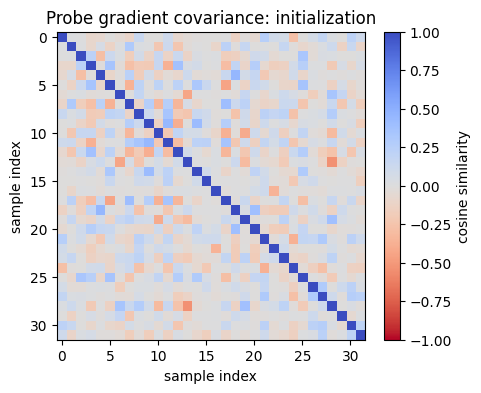

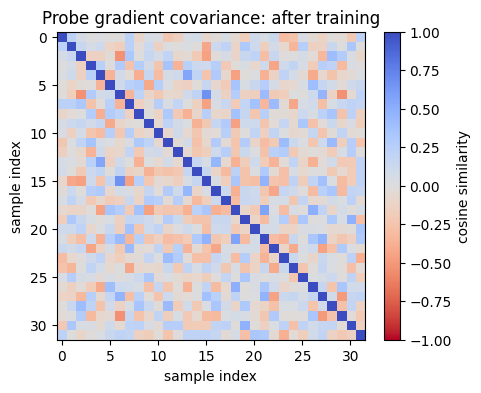

In [18]:
def per_sample_probe_gradient_covariance(model, x_probe, max_samples=32):
    model_cpu = copy.deepcopy(model).to(hessian_device).eval().float()
    x = x_probe[:max_samples].to(hessian_device).float()

    with torch.no_grad():
        y_stop = model_cpu(x).detach()
        epsilon = torch.randn_like(y_stop)
        target = y_stop - epsilon

    grads = []
    for i in range(x.size(0)):
        model_cpu.zero_grad(set_to_none=True)
        pred_i = model_cpu(x[i:i+1])
        loss_i = F.mse_loss(pred_i, target[i:i+1], reduction='mean')
        grad_i = torch.autograd.grad(loss_i, model_cpu.parameters(), retain_graph=False, create_graph=False)
        grad_i = torch.cat([g.detach().reshape(-1) for g in grad_i])
        grads.append(grad_i)

    G = torch.stack(grads, dim=0)
    G = G / (G.norm(dim=1, keepdim=True) + 1e-12)
    C = G @ G.T
    return C.cpu().numpy()

# Compare gradient covariance before and after training using the same probe batch.
model_init = SmallMLP(hidden_width=hidden_width).to(train_device)
model_init.load_state_dict(initial_state)

C_init = per_sample_probe_gradient_covariance(model_init, probe_x, max_samples=probe_batch_size)
C_trained = per_sample_probe_gradient_covariance(model, probe_x, max_samples=probe_batch_size)

plt.figure(figsize=(5, 4))
plt.imshow(C_init, vmin=-1, vmax=1, cmap='coolwarm_r')
plt.colorbar(label='cosine similarity')
plt.title('Probe gradient covariance: initialization')
plt.xlabel('sample index')
plt.ylabel('sample index')
plt.show()

plt.figure(figsize=(5, 4))
plt.imshow(C_trained, vmin=-1, vmax=1, cmap='coolwarm_r')
plt.colorbar(label='cosine similarity')
plt.title('Probe gradient covariance: after training')
plt.xlabel('sample index')
plt.ylabel('sample index')
plt.show()


## Interpretation guide

Look mainly at:

- `lambda_max` / spectral radius: larger values mean sharper local curvature for this random perturbation probe.
- More large positive outliers after training: evidence that the trained parameters have moved to a sharper region for arbitrary prediction changes.
- More negative eigenvalues: locally more non-convex probe geometry.
- Gradient covariance off-diagonal structure: strong positive or negative off-diagonal values mean gradients for different inputs are less independent.

For larger networks, replace exact Hessian computation with Hessian-vector products plus Lanczos/SLQ. Exact Hessian construction becomes impractical quickly because memory grows quadratically with parameter count.
